<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Constant002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

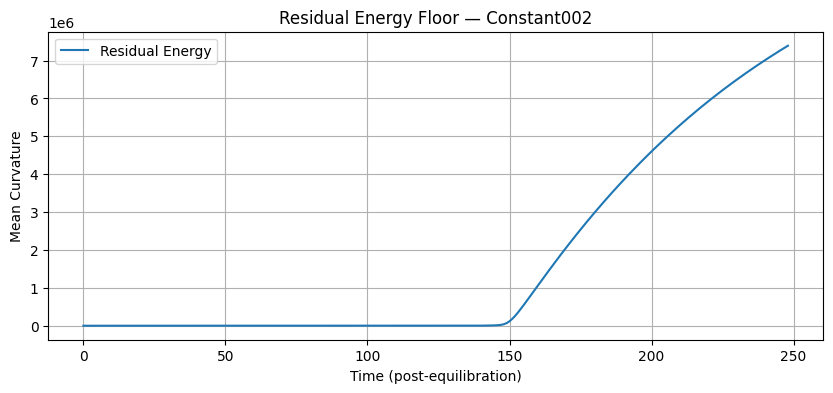

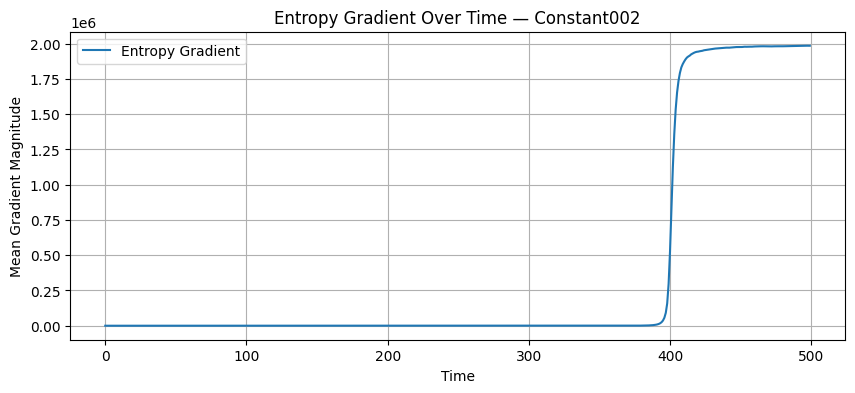

In [2]:
# 🌀 Constant002 — The Whisper Under Strain
# Arc III: The Constant Whisper
# Glyph: Λ — The Whisper Constant
# Objective: Test Λ emergence under increased ξ imbalance with overflow protection

import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
size = 100            # Grid size
steps = 500           # Time steps
ξ = 0.06              # Increased imbalance parameter
noise_amp = 1e-3      # Vacuum fluctuation mimic
damping = 0.01        # Damping factor
sequestration_enabled = True  # Toggle for entropic sequestration

# Initialize lattice
entropy = np.random.rand(size, size)
curvature = np.zeros((size, size))
residual_energy = []
entropy_gradients = []

# --- Evolution Loop ---
for t in range(steps):
    # Inject noise to mimic vacuum fluctuations
    noise = noise_amp * np.random.randn(size, size)

    # Compute entropy gradient magnitude with clipping
    grad_x, grad_y = np.gradient(entropy)
    grad_x = np.clip(grad_x, -1e3, 1e3)
    grad_y = np.clip(grad_y, -1e3, 1e3)
    flow = grad_x**2 + grad_y**2
    entropy_gradients.append(np.nanmean(flow))

    # Update curvature with overflow protection
    curvature += ξ * flow - damping * curvature + noise
    curvature = np.nan_to_num(curvature, nan=0.0, posinf=1e6, neginf=0.0)

    # Apply entropic sequestration (clip extreme curvature)
    if sequestration_enabled:
        threshold = np.nanpercentile(curvature, 95)
        curvature = np.clip(curvature, 0, threshold)

    # Update entropy based on curvature feedback
    entropy += curvature * damping

    # Track residual energy after equilibration
    if t > steps // 2:
        residual_energy.append(np.nanmean(curvature))

# --- Plot Residual Energy ---
plt.figure(figsize=(10, 4))
plt.plot(residual_energy, label='Residual Energy')
plt.title("Residual Energy Floor — Constant002")
plt.xlabel("Time (post-equilibration)")
plt.ylabel("Mean Curvature")
plt.grid(True)
plt.legend()
plt.show()

# --- Plot Entropy Gradient Over Time ---
plt.figure(figsize=(10, 4))
plt.plot(entropy_gradients, label='Entropy Gradient')
plt.title("Entropy Gradient Over Time — Constant002")
plt.xlabel("Time")
plt.ylabel("Mean Gradient Magnitude")
plt.grid(True)
plt.legend()
plt.show()
